In [4]:
import os
import pandas as pd

results_fpath = os.path.join("..", "..", "tests", "data", "HR_gene_results.tsv")
results_df = pd.read_csv(results_fpath, delimiter='\t', header=0, index_col= 0)


print(results_df[0:2])


                               Pathogenicity proved             Type mutation  \
tx_id                                                                           
ENST00000381418-8                               NaN                 canonical   
ENST00000381418-8-22130605-T-C                  Yes  stop codon loss mutation   

                                NuORFs  0uORF_length  0Is_ouORF       0GC  \
tx_id                                                                       
ENST00000381418-8                    4            51      False  0.627451   
ENST00000381418-8-22130605-T-C       4            51      False  0.627451   

                                0GCplus  0ID  0Cap_distance  0Kozak  ...  2ID  \
tx_id                                                                ...        
ENST00000381418-8                   0.9  556             16       2  ...   47   
ENST00000381418-8-22130605-T-C      0.9  556             16       2  ...   47   

                                2Cap_dist

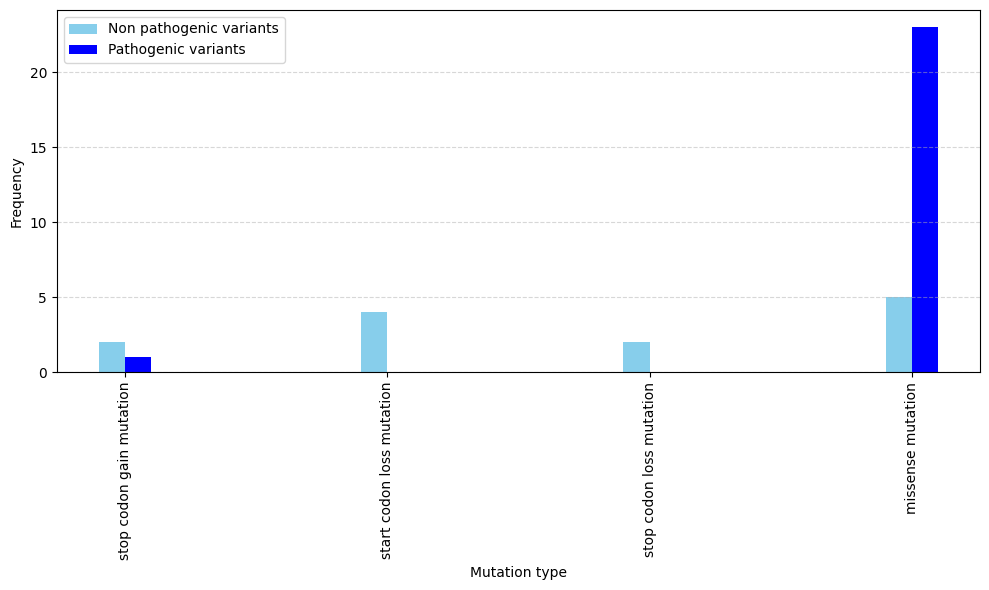

In [8]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

df_without_canonical = results_df[1:]
df_patho = df_without_canonical[df_without_canonical["Pathogenicity proved"] == "Yes"]
df_no_patho = df_without_canonical[df_without_canonical["Pathogenicity proved"] == "No"]

df_patho_type_dict = {}
for type in df_patho["Type mutation"]:
    if type in df_patho_type_dict:
        df_patho_type_dict[type] += 1
    else:
        df_patho_type_dict[type] = 1

df_no_patho_type_dict = {}
for type in df_no_patho["Type mutation"]:
    if type in df_no_patho_type_dict:
        df_no_patho_type_dict[type] += 1
    else:
        df_no_patho_type_dict[type] = 1

all_keys = set(df_patho_type_dict.keys()).union(set(df_no_patho_type_dict.keys()))

values_df_patho_type_dict = [df_patho_type_dict.get(key, 0) for key in all_keys]
values_df_no_patho_type_dict = [df_no_patho_type_dict.get(key, 0) for key in all_keys]

labels = list(all_keys)

x = np.arange(len(all_keys))
width = 0.1 

plt.figure(figsize=(10,6))
plt.bar(x - width/2, values_df_patho_type_dict, width, label='Non pathogenic variants', color='skyblue')
plt.bar(x + width/2, values_df_no_patho_type_dict, width, label='Pathogenic variants', color='blue')

plt.xlabel('Mutation type')
plt.ylabel('Frequency')
plt.xticks(x, labels, rotation=90)

plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

